![image.png](https://i.imgur.com/a3uAqnb.png)

# Linear Attention and the Delta Rule: Training a Gated DeltaNet Language Model

- **Dataset**: [TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories) from Hugging Face, 2.1 million short stories in simple English (Eldan and Li, 2023)
- **Task**: next-token language modelling, then a decode-memory measurement and a copying probe
- **Model**: a Gated DeltaNet language model (about 60M parameters) from the `flash-linear-attention` library and a same-size Transformer (`LlamaForCausalLM`), both trained from scratch
- **Runtime**: Colab A100 GPU 

In this lab, we will:

- build a Gated DeltaNet language model with the library used by Qwen3-Next and Kimi Linear, and a same-size softmax-attention Transformer
- train both from scratch on real text with one training loop and compare their loss curves
- measure what each model keeps in memory while decoding, and how well each copies a passage it has just read
- implement the gated delta rule by hand and check it against the library kernel

## What is the gated delta rule?

Softmax attention keeps every past key and value, so its memory grows with the sequence. A linear-attention layer instead keeps one fixed-size matrix per head, the state $S_t$, and updates it once per token. Plain linear attention only adds to this state, $S_t = S_{t-1} + v_t k_t^\top$, so it can neither forget nor correct an entry. Gated DeltaNet adds both abilities: a scalar gate shrinks the whole state, and the delta rule overwrites what is stored along the current key before writing the new value.

$$S_t = S_{t-1}\,\big(\alpha_t\,(I - \beta_t\, k_t k_t^\top)\big) + \beta_t\, v_t k_t^\top, \qquad o_t = S_t\, q_t$$

Where:
- $S_t \in \mathbb{R}^{d_v \times d_k}$ is the state of one head after token $t$
- $q_t, k_t \in \mathbb{R}^{d_k}$ and $v_t \in \mathbb{R}^{d_v}$ are the query, key and value of token $t$, with $q_t$ and $k_t$ normalised to unit length
- $\alpha_t \in (0, 1)$ is the forget gate, one scalar per head and token, and $\beta_t \in (0, 1)$ is the writing strength
- $I - \beta_t k_t k_t^\top$ erases the old content stored along $k_t$, and $\beta_t v_t k_t^\top$ writes the new value there

The update is one gradient step on $\tfrac{1}{2}\lVert S k_t - v_t \rVert^2$, so the state is a small regression model that learns to map keys to values online. Because $S_t$ has a fixed size, decoding costs the same at every position.

Paper: [Yang et al., 2025. Gated Delta Networks: Improving Mamba2 with Delta Rule](https://arxiv.org/abs/2412.06464)

## Setup

This lab needs an A100 GPU: in Google Colab, select **Runtime > Change runtime type > A100 GPU** (40 GB or 80 GB, the lab uses about 12 GB), then run the cells from top to bottom. The `flash-linear-attention` kernels are written in Triton and need a CUDA GPU.

In [ ]:
%pip install -q "flash-linear-attention[cuda]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.2/819.2 kB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.6/399.6 kB 35.6 MB/s eta 0:00:00


In [ ]:
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, LlamaConfig, LlamaForCausalLM

from fla.models import GatedDeltaNetConfig, GatedDeltaNetForCausalLM
from fla.ops.gated_delta_rule import chunk_gated_delta_rule

Every size and length knob lives in this cell. `N_TRAIN` stories are packed into `SEQ_LEN`-token sequences and each model sees at most `MAX_STEPS` batches, about 50M tokens. The two model configurations are matched in total parameter count by giving the Transformer a wider MLP, since the Gated DeltaNet mixer doubles its value dimension.

In [ ]:
SEED = 42
N_TRAIN = 300_000        # stories to tokenise (the first train shard holds about 530,000)
N_VAL = 2_000            # held-out stories
SEQ_LEN = 512            # tokens per training sequence
BATCH_SIZE = 32          # sequences per step, so 16,384 tokens per step
EPOCHS = 1
MAX_STEPS = 3_000        # cap on optimizer steps per epoch and per model, about 50M tokens
LR = 1e-3                # uses 1e-3 with a cosine schedule for small models
WARMUP_STEPS = 100
WEIGHT_DECAY = 0.1
LOG_EVERY = 50           # steps between recorded training losses
EVAL_EVERY = 500         # steps between validation losses
NUM_WORKERS = 2          # DataLoader worker processes

HIDDEN_SIZE = 512
N_LAYERS = 8
GDN_HEADS = 4            # Gated DeltaNet heads, each with a 128 x 256 state (head_dim x 2 head_dim)
GDN_HEAD_DIM = 128
GDN_MLP_SIZE = 1536
TFM_HEADS = 8            # Transformer attention heads of dimension 64
TFM_MLP_SIZE = 2048      # wider than the Gated DeltaNet MLP so that the parameter counts match
MAX_POSITIONS = 4096     # longest sequence either model accepts, used by the memory measurement

MAX_NEW_TOKENS = 48
PROBE_LENGTHS = [32, 64, 128, 256]            # passage lengths for the copying probe (2 x length <= SEQ_LEN)
CACHE_LENGTHS = [256, 512, 1024, 2048, 4096]  # prompt lengths for the decode-memory measurement

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} | device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)} "
          f"({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")
    torch.set_float32_matmul_precision("high")
else:
    print("No GPU found. The Triton kernels need CUDA, so this lab cannot train here. "
          "In Colab: Runtime > Change runtime type > A100 GPU.")

# Mixed precision: bfloat16 on an A100 or newer (no gradient scaler needed), float16 with a scaler
# on an older GPU, off on the CPU.
USE_AMP = DEVICE == "cuda"
AMP_DTYPE = torch.bfloat16 if USE_AMP and torch.cuda.get_device_capability(0)[0] >= 8 else torch.float16
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP and AMP_DTYPE == torch.float16)

PyTorch 2.11.0+cu130 | device: cuda
GPU: NVIDIA A100-SXM4-40GB (42.4 GB)


## 1. Dataset

- **Source**: [TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories) on Hugging Face (Eldan and Li, 2023)
- **Content**: 2,119,719 training stories and 21,990 validation stories, one `text` column, written by GPT-3.5 and GPT-4 with the vocabulary of a young child
- **Licence**: CDLA-Sharing-1.0
- **What we use**: the first of the four training parquet shards (about 250 MB) and the validation shard, from which we take `N_TRAIN` training and `N_VAL` validation stories

Small models learn fluent English on this corpus within minutes, which makes two architectures comparable in a short run. We tokenise with the GPT-2 byte-pair tokenizer (50,257 tokens).

In [ ]:
dataset = load_dataset(
    "roneneldan/TinyStories",
    data_files={"train": "data/train-00000-of-00004-*.parquet",
                "validation": "data/validation-*.parquet"},
)
train_split = dataset["train"].shuffle(seed=SEED).select(range(N_TRAIN))
val_split = dataset["validation"].shuffle(seed=SEED).select(range(N_VAL))

tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")
EOS_ID = tokenizer.eos_token_id
print(dataset)
print(f"vocabulary: {len(tokenizer):,} tokens, end-of-text id {EOS_ID}")

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…): reconstructing file:   0%|          |  0.00B /  249MB            

data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes:           |  0.00B            

data/validation-00000-of-00001-869c898b5(…): reconstructing file:   0%|          |  0.00B / 9.99MB            

data/validation-00000-of-00001-869c898b5(…): downloading bytes:           |  0.00B            

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 529930
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})
vocabulary: 50,257 tokens, end-of-text id 50256


We look at one story and at how long the stories are in tokens, which tells us how many training sequences `N_TRAIN` stories give.

In [ ]:
print(train_split[0]["text"][:600])
print()
sample_lengths = [len(ids) for ids in tokenizer(train_split[:1000]["text"])["input_ids"]]
print(f"tokens per story (first 1,000): mean {np.mean(sample_lengths):.0f}, "
      f"min {min(sample_lengths)}, max {max(sample_lengths)}")
print(f"about {N_TRAIN * np.mean(sample_lengths) / 1e6:.0f}M training tokens, "
      f"about {N_TRAIN * np.mean(sample_lengths) / SEQ_LEN:,.0f} sequences of {SEQ_LEN} tokens")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1047 > 1024). Running this sequence through the model will result in indexing errors


Once upon a time, there was a young girl who wanted to go for a round. She wore her shoes and went outside. She jumped and skipped around the little park, twirling and spinning around. She looked so young and happy.

The girl explored the park. She climbed on the monkey bars and slid down the slide. Then she went to the sandbox and dug her way around, finding hidden little treasures in the sand.

After a while, the girl got tired, so she stopped to rest. She watched the other children playing and laughed with them. She felt so lucky to be young and playing outside.

Finally, when the sun was g

tokens per story (first 1,000): mean 217, min 80, max 1047
about 65M training tokens, about 127,157 sequences of 512 tokens


Language models are trained on packed text: we append an end-of-text token to every story, concatenate everything into one long token stream and cut it into `SEQ_LEN` pieces, so no padding is wasted. The `Dataset` returns one piece, and the model shifts it internally to form the targets.

In [ ]:
def pack_tokens(split, chunk=5_000):
    """Tokenise a split in chunks and pack it into rows of SEQ_LEN tokens. Returns a LongTensor (n_seq, SEQ_LEN)."""
    pieces = []
    for start in tqdm(range(0, len(split), chunk), desc="tokenising", leave=False):
        for ids in tokenizer(split[start:start + chunk]["text"])["input_ids"]:
            pieces.append(np.asarray(ids + [EOS_ID], dtype=np.int32))
    stream = np.concatenate(pieces)                       # (n_tokens,)
    n_seq = len(stream) // SEQ_LEN
    return torch.from_numpy(stream[: n_seq * SEQ_LEN].astype(np.int64)).view(n_seq, SEQ_LEN)


class PackedDataset(Dataset):
    """Rows of SEQ_LEN token ids. The model builds the shifted targets itself."""

    def __init__(self, ids):
        self.ids = ids

    def __len__(self):
        return self.ids.size(0)

    def __getitem__(self, i):
        return self.ids[i]


train_ids = pack_tokens(train_split)
val_ids = pack_tokens(val_split)
train_loader = DataLoader(PackedDataset(train_ids), batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                          num_workers=NUM_WORKERS, pin_memory=DEVICE == "cuda")
val_loader = DataLoader(PackedDataset(val_ids), batch_size=BATCH_SIZE,
                        num_workers=NUM_WORKERS, pin_memory=DEVICE == "cuda")

batch = next(iter(train_loader))
print(f"train sequences: {train_ids.shape}, validation sequences: {val_ids.shape}")
print(f"one batch: {tuple(batch.shape)}   # (BATCH_SIZE, SEQ_LEN)")

tokenising:   0%|          | 0/60 [00:00<?, ?it/s]

tokenising:   0%|          | 0/1 [00:00<?, ?it/s]

train sequences: torch.Size([131590, 512]), validation sequences: torch.Size([856, 512])
one batch: (32, 512)   # (BATCH_SIZE, SEQ_LEN)


## 2. Model

Both models are stacks of `N_LAYERS` pre-norm blocks, each a token mixer followed by a gated MLP, with tied embeddings. They differ only in the mixer.

The **Gated DeltaNet** block projects the input to $q_t$, $k_t$, $v_t$, passes each through a short causal convolution (four positions) with a SiLU activation, and produces two scalars per head: the gate $\alpha_t = \exp(g_t)$ with $g_t = -\exp(A_{\log})\,\mathrm{softplus}(a_t + b_{dt})$, and the writing strength $\beta_t = \sigma(b_t)$, where $a_t$ and $b_t$ are linear projections of the input and $A_{\log}$, $b_{dt}$ are learned per-head parameters. The recurrence of the primer then runs inside a Triton kernel that processes the tokens in chunks, so training is parallel while the state stays one $d_k \times d_v$ matrix per head. The output is gated, normalised and projected back.

The **Transformer** block is a standard `Llama` decoder layer: rotary position embeddings, multi-head softmax attention through PyTorch's scaled-dot-product kernel, and a SwiGLU MLP. During decoding it keeps a key and a value vector for every past token in every layer.

In [ ]:
gdn_config = GatedDeltaNetConfig(
    vocab_size=len(tokenizer),
    hidden_size=HIDDEN_SIZE,
    num_hidden_layers=N_LAYERS,
    num_heads=GDN_HEADS,
    head_dim=GDN_HEAD_DIM,
    expand_v=2,                      # value dimension 2 x head_dim, as in the paper and Qwen3-Next
    intermediate_size=GDN_MLP_SIZE,
    max_position_embeddings=MAX_POSITIONS,
    tie_word_embeddings=True,
    bos_token_id=EOS_ID, eos_token_id=EOS_ID, pad_token_id=EOS_ID,
)
tfm_config = LlamaConfig(
    vocab_size=len(tokenizer),
    hidden_size=HIDDEN_SIZE,
    num_hidden_layers=N_LAYERS,
    num_attention_heads=TFM_HEADS,
    num_key_value_heads=TFM_HEADS,
    intermediate_size=TFM_MLP_SIZE,
    max_position_embeddings=MAX_POSITIONS,
    tie_word_embeddings=True,
    bos_token_id=EOS_ID, eos_token_id=EOS_ID, pad_token_id=EOS_ID,
)

GatedDeltaNetForCausalLM._tied_weights_keys = {"lm_head.weight": "model.embeddings.weight"}

models = {
    "Gated DeltaNet": GatedDeltaNetForCausalLM(gdn_config).to(DEVICE),
    "Transformer": LlamaForCausalLM(tfm_config).to(DEVICE),
}
for name, model in models.items():
    n_params = sum(p.numel() for p in model.parameters())
    n_embed = model.get_input_embeddings().weight.numel()
    print(f"{name:15s}: {n_params / 1e6:6.1f}M parameters, of which {n_embed / 1e6:.1f}M in the tied embedding")

Gated DeltaNet :   61.5M parameters, of which 25.7M in the tied embedding
Transformer    :   59.3M parameters, of which 25.7M in the tied embedding


Before training, both models predict tokens at random, so their cross-entropy should sit near $\ln(50{,}257) \approx 10.8$ nats. We keep this baseline for the results section.

In [ ]:
@torch.no_grad()
def evaluate(model, loader, max_batches=None):
    """Mean next-token cross-entropy (nats per token) on a held-out loader."""
    model.eval()
    total, n = 0.0, 0
    for i, ids in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        ids = ids.to(DEVICE)
        with torch.autocast(device_type=DEVICE, dtype=AMP_DTYPE, enabled=USE_AMP):
            loss = model(input_ids=ids, labels=ids).loss     # labels are shifted inside the model
        total += loss.item()
        n += 1
    model.train()
    return total / max(n, 1)


baseline = {name: evaluate(model, val_loader) for name, model in models.items()}
for name, loss in baseline.items():
    print(f"untrained {name:15s}: validation loss {loss:.3f} nats, perplexity {math.exp(loss):,.0f}")

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


untrained Gated DeltaNet : validation loss 10.905 nats, perplexity 54,441
untrained Transformer    : validation loss 10.951 nats, perplexity 57,000


## 3. Training

Both models minimise the next-token cross-entropy with AdamW (weight decay 0.1), a linear warm-up of `WARMUP_STEPS` steps, a cosine decay to one tenth of `LR` and gradients clipped to norm 1, the recipe of the `flame` training framework for small `fla` models. One function trains one epoch of at most `MAX_STEPS` batches and records the training loss every `LOG_EVERY` steps and the validation loss every `EVAL_EVERY` steps.

Expected time: about 5 to 6 minutes per model on an A100, about 11 minutes for this section.

In [ ]:
def make_optimizer(model, total_steps):
    """AdamW with linear warm-up and cosine decay to 0.1 x LR."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.95))

    def lr_lambda(step):
        if step < WARMUP_STEPS:
            return (step + 1) / WARMUP_STEPS
        progress = (step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
        return 0.1 + 0.9 * 0.5 * (1 + math.cos(math.pi * min(1.0, progress)))

    return optimizer, torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def train_one_epoch(model, loader, optimizer, scheduler, history, step):
    """One pass over the loader, capped at MAX_STEPS batches. Returns the mean loss and the global step."""
    model.train()
    total, n = 0.0, 0
    # Pass an iterator, not the loader: given a loader, tqdm.auto calls iter() on it once more for
    # itself, which starts an extra set of worker processes every epoch that is never used or shut down.
    progress = tqdm(iter(loader), total=min(len(loader), MAX_STEPS), desc="train", leave=False)
    for ids in progress:
        if n >= MAX_STEPS:
            break
        ids = ids.to(DEVICE, non_blocking=True)                   # (BATCH_SIZE, SEQ_LEN)
        with torch.autocast(device_type=DEVICE, dtype=AMP_DTYPE, enabled=USE_AMP):
            loss = model(input_ids=ids, labels=ids).loss
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()                              # the scaler is a no-op when disabled
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        step += 1
        total += loss.item()
        n += 1
        if step % LOG_EVERY == 0:
            history["step"].append(step)
            history["train_loss"].append(loss.item())
        if step % EVAL_EVERY == 0:
            history["val_step"].append(step)
            history["val_loss"].append(evaluate(model, val_loader, max_batches=20))
        progress.set_postfix(loss=f"{loss.item():.3f}", lr=f"{scheduler.get_last_lr()[0]:.1e}")
    return total / max(n, 1), step

In [ ]:
steps_per_epoch = min(len(train_loader), MAX_STEPS)
print(f"{steps_per_epoch:,} optimizer steps per epoch, {EPOCHS} epoch(s), "
      f"{steps_per_epoch * EPOCHS * BATCH_SIZE * SEQ_LEN / 1e6:.0f}M tokens per model")

histories = {}
for name, model in models.items():
    torch.manual_seed(SEED)                       # same data order for both models
    optimizer, scheduler = make_optimizer(model, steps_per_epoch * EPOCHS)
    history = {"step": [], "train_loss": [], "val_step": [], "val_loss": [], "epoch_val_loss": [], "epoch_time": []}
    start = time.time()
    step = 0
    for epoch in range(1, EPOCHS + 1):
        train_loss, step = train_one_epoch(model, train_loader, optimizer, scheduler, history, step)
        val_loss = evaluate(model, val_loader)
        history["epoch_val_loss"].append(val_loss)
        history["epoch_time"].append(time.time() - start)
        print(f"{name} | epoch {epoch}/{EPOCHS}: train loss {train_loss:.4f} | val loss {val_loss:.4f}, "
              f"perplexity {math.exp(val_loss):.1f} | {time.time() - start:.0f}s elapsed")
    histories[name] = history
    del optimizer, scheduler

3,000 optimizer steps per epoch, 1 epoch(s), 49M tokens per model


train:   0%|          | 0/3000 [00:00<?, ?it/s]

Gated DeltaNet | epoch 1/1: train loss 2.0185 | val loss 1.6086, perplexity 5.0 | 638s elapsed


train:   0%|          | 0/3000 [00:00<?, ?it/s]

Transformer | epoch 1/1: train loss 2.1523 | val loss 1.6523, perplexity 5.2 | 414s elapsed


## 4. Results

The training loss is sampled every `LOG_EVERY` steps and the validation loss every `EVAL_EVERY` steps, both plotted against the optimizer step for the two models.

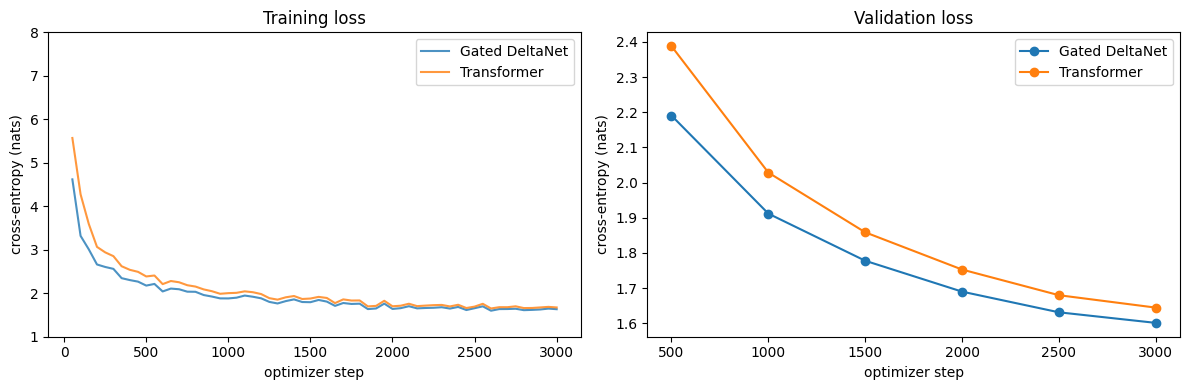

Gated DeltaNet : untrained 10.905 -> trained 1.609 nats (perplexity 5.0), 10.6 min of training
Transformer    : untrained 10.951 -> trained 1.652 nats (perplexity 5.2), 6.9 min of training


In [ ]:
fig, (ax_train, ax_val) = plt.subplots(1, 2, figsize=(12, 4))
for name, history in histories.items():
    ax_train.plot(history["step"], history["train_loss"], label=name, alpha=0.8)
    ax_val.plot(history["val_step"], history["val_loss"], marker="o", label=name)
ax_train.set(xlabel="optimizer step", ylabel="cross-entropy (nats)", title="Training loss", ylim=(1, 8))
ax_val.set(xlabel="optimizer step", ylabel="cross-entropy (nats)", title="Validation loss")
ax_train.legend()
ax_val.legend()
plt.tight_layout()
plt.show()

for name in models:
    print(f"{name:15s}: untrained {baseline[name]:.3f} -> trained {histories[name]['epoch_val_loss'][-1]:.3f} nats "
          f"(perplexity {math.exp(histories[name]['epoch_val_loss'][-1]):.1f}), "
          f"{histories[name]['epoch_time'][-1] / 60:.1f} min of training")

### Stories from both models

We decode greedily, one token at a time, by running the full prefix through the model at every step. This is the simplest decoder and treats both architectures alike. A production decoder would instead reuse the cache we measure in the next part.

In [ ]:
@torch.no_grad()
def greedy_generate(model, prompt, max_new_tokens=MAX_NEW_TOKENS):
    """Greedy decoding without a cache: the whole prefix is re-encoded at every step."""
    model.eval()
    ids = tokenizer(prompt, return_tensors="pt").input_ids.to(DEVICE)       # (1, prompt_len)
    for _ in range(max_new_tokens):
        with torch.autocast(device_type=DEVICE, dtype=AMP_DTYPE, enabled=USE_AMP):
            logits = model(input_ids=ids).logits                               # (1, T, vocab)
        next_id = logits[:, -1].argmax(dim=-1, keepdim=True)                   # (1, 1)
        ids = torch.cat([ids, next_id], dim=1)
        if next_id.item() == EOS_ID:
            break
    return tokenizer.decode(ids[0])


prompt = "Once upon a time, there was a little girl named Lily. One day, she found a"
for name, model in models.items():
    print(f"--- {name} ---")
    print(greedy_generate(model, prompt))
    print()

--- Gated DeltaNet ---
Once upon a time, there was a little girl named Lily. One day, she found a shiny penny on the ground. She picked it up and showed it to her mom. "Look, Mommy! I found a penny!" she said.

Her mom smiled and said, "That's a very nice penny, Lily

--- Transformer ---
Once upon a time, there was a little girl named Lily. One day, she found a shiny rock on the ground. She picked it up and showed it to her mom. "Look, Mommy! I found a pretty rock!" she said.

Her mom smiled and said, "That's a very pretty rock,



### What each model keeps in memory while decoding

A decoding model stores whatever the next token needs from the past. For the Transformer that is a key and a value vector per past token and layer, so the cache grows linearly with the prompt. For Gated DeltaNet it is the state $S_t$ of every head plus the last positions of the short convolution, whose size does not depend on the prompt. We prefill prompts of increasing length with `use_cache=True` and add up the bytes of every tensor in the returned cache.

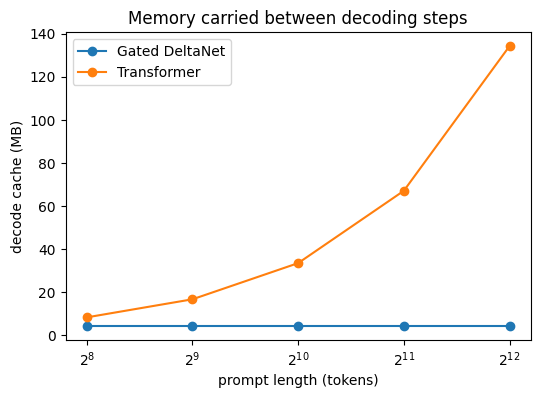

Gated DeltaNet : 256: 4.33 MB, 512: 4.33 MB, 1024: 4.33 MB, 2048: 4.33 MB, 4096: 4.33 MB
Transformer    : 256: 8.39 MB, 512: 16.78 MB, 1024: 33.55 MB, 2048: 67.11 MB, 4096: 134.22 MB


In [ ]:
def tensor_bytes(obj, seen=None, depth=0):
    """Total bytes of all tensors reachable from obj (through dicts, lists, tuples and attributes)."""
    seen = set() if seen is None else seen
    if id(obj) in seen or depth > 6:
        return 0
    seen.add(id(obj))
    if torch.is_tensor(obj):
        return obj.numel() * obj.element_size()
    if isinstance(obj, dict):
        return sum(tensor_bytes(v, seen, depth + 1) for v in obj.values())
    if isinstance(obj, (list, tuple)):
        return sum(tensor_bytes(v, seen, depth + 1) for v in obj)
    if hasattr(obj, "__dict__"):
        return sum(tensor_bytes(v, seen, depth + 1) for v in vars(obj).values())
    return 0


@torch.no_grad()
def cache_megabytes(model, length):
    """Prefill one prompt of the given length and measure the cache it leaves behind."""
    model.eval()
    ids = val_ids[:1, :1].repeat(1, length) if length > val_ids.size(1) else val_ids[:1, :length]
    with torch.autocast(device_type=DEVICE, dtype=AMP_DTYPE, enabled=USE_AMP):
        out = model(input_ids=ids.to(DEVICE), use_cache=True)
    return tensor_bytes(out.past_key_values) / 1e6


cache_sizes = {name: [cache_megabytes(model, L) for L in CACHE_LENGTHS] for name, model in models.items()}
plt.figure(figsize=(6, 4))
for name, sizes in cache_sizes.items():
    plt.plot(CACHE_LENGTHS, sizes, marker="o", label=name)
plt.xscale("log", base=2)
plt.xlabel("prompt length (tokens)")
plt.ylabel("decode cache (MB)")
plt.title("Memory carried between decoding steps")
plt.legend()
plt.show()
for name, sizes in cache_sizes.items():
    print(f"{name:15s}: " + ", ".join(f"{L}: {mb:.2f} MB" for L, mb in zip(CACHE_LENGTHS, sizes)))

### A copying probe

A fixed-size state must compress everything it has read, while attention can look any token up again. We show each model a held-out passage of `L` tokens twice in a row and score only the second copy: the loss and next-token accuracy on text the model has just read. Every length stays within `SEQ_LEN`, the longest sequence the models were trained on.

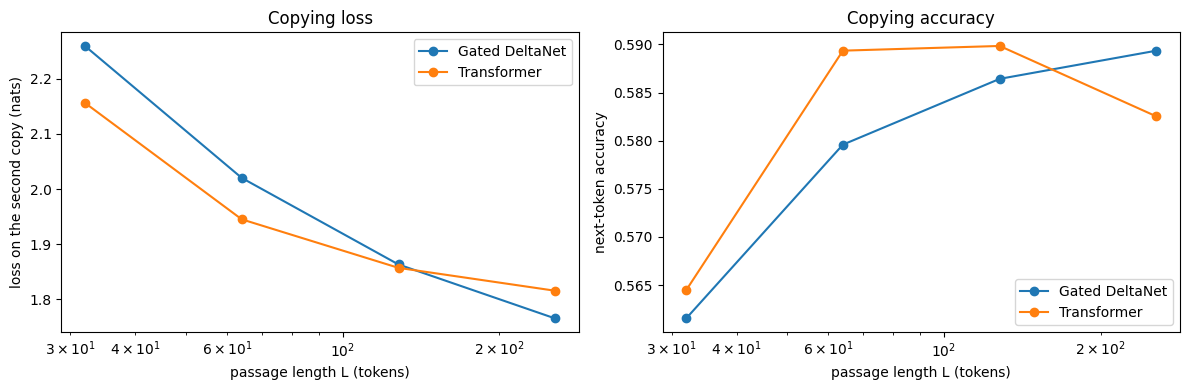

In [ ]:
@torch.no_grad()
def copy_probe(model, L, n_passages=32):
    """Loss and accuracy on the second copy of a repeated held-out passage of L tokens."""
    model.eval()
    passages = val_ids[:n_passages, :L]                          # (n, L) real text
    ids = torch.cat([passages, passages], dim=1).to(DEVICE)      # (n, 2L): the passage, then itself again
    with torch.autocast(device_type=DEVICE, dtype=AMP_DTYPE, enabled=USE_AMP):
        logits = model(input_ids=ids).logits.float()             # (n, 2L, vocab)
    pred = logits[:, L - 1:2 * L - 1]                            # predictions for positions L .. 2L-1
    target = ids[:, L:]
    loss = F.cross_entropy(pred.reshape(-1, pred.size(-1)), target.reshape(-1))
    acc = (pred.argmax(dim=-1) == target).float().mean()
    return loss.item(), acc.item()


probe = {name: [copy_probe(model, L) for L in PROBE_LENGTHS] for name, model in models.items()}
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))
for name, rows in probe.items():
    ax_loss.plot(PROBE_LENGTHS, [r[0] for r in rows], marker="o", label=name)
    ax_acc.plot(PROBE_LENGTHS, [r[1] for r in rows], marker="o", label=name)
ax_loss.set(xlabel="passage length L (tokens)", ylabel="loss on the second copy (nats)", title="Copying loss", xscale="log")
ax_acc.set(xlabel="passage length L (tokens)", ylabel="next-token accuracy", title="Copying accuracy", xscale="log")
ax_loss.legend()
ax_acc.legend()
plt.tight_layout()
plt.show()

**What to notice**

With the same data, steps and parameter budget, the two loss curves run close together and both end far below the untrained baseline: a mixer with a fixed-size state learns language modelling about as well as softmax attention at this scale. The memory plot separates them. The Transformer's cache is a straight line through the origin while the Gated DeltaNet cache is flat, and the crossing point, a few hundred tokens here, is where a recurrent mixer starts to pay off. The copying probe shows the price: attention copies a passage it has just seen almost perfectly at every length, while the fixed-size state copies short passages well and degrades as the passage grows past what one matrix per head can hold. Hybrid models keep a few attention layers to buy back this recall.

## 5. The Recurrent Form by Hand

The Triton kernel runs the recurrence in chunks, which makes training fast, but the recurrence itself is five lines. We write the token-by-token form of the primer's equation with random inputs of the model's shapes and compare its outputs and final state with `chunk_gated_delta_rule`, the kernel inside every block we trained.

Two library conventions matter: it stores the transpose of the primer's state, $S^\top \in \mathbb{R}^{d_k \times d_v}$, so the read is $q_t^\top S^\top$, it normalises $q_t$ and $k_t$ to unit length and scales the query by $1/\sqrt{d_k}$, and it takes the gate in log space, $g_t = \log \alpha_t$.

In [ ]:
def gated_delta_rule_by_hand(q, k, v, g, beta):
    """Token-by-token gated delta rule for one layer.
    q, k: (B, T, H, K)   v: (B, T, H, V)   g: (B, T, H) log-space gate   beta: (B, T, H) in (0, 1).
    Returns o: (B, T, H, V) and the final state S: (B, H, K, V), the library's layout."""
    B, T, H, K = q.shape
    V = v.shape[-1]
    q = F.normalize(q, dim=-1) * K ** -0.5                            # unit-length queries, scaled by 1/sqrt(d_k)
    k = F.normalize(k, dim=-1)                                        # unit-length keys
    S = q.new_zeros(B, H, K, V)
    outputs = []
    for t in range(T):
        q_t, k_t, v_t = q[:, t], k[:, t], v[:, t]                     # (B, H, K), (B, H, K), (B, H, V)
        S = S * g[:, t].exp()[..., None, None]                        # forget: alpha_t S_{t-1}
        retrieved = torch.einsum("bhk,bhkv->bhv", k_t, S)             # what the memory currently holds for k_t
        delta = beta[:, t][..., None] * (v_t - retrieved)             # the error, scaled by the writing strength
        S = S + torch.einsum("bhk,bhv->bhkv", k_t, delta)             # rank-1 correction along k_t
        outputs.append(torch.einsum("bhk,bhkv->bhv", q_t, S))         # read with the query
    return torch.stack(outputs, dim=1), S


B, T, H, K = 2, 64, GDN_HEADS, GDN_HEAD_DIM
V = 2 * K
torch.manual_seed(SEED)
q, k = torch.randn(B, T, H, K, device=DEVICE), torch.randn(B, T, H, K, device=DEVICE)
v = torch.randn(B, T, H, V, device=DEVICE)
A_log = torch.log(torch.empty(H, device=DEVICE).uniform_(1, 16))        # the layer's per-head decay parameter
dt_bias = torch.zeros(H, device=DEVICE)
a, b = torch.randn(B, T, H, device=DEVICE), torch.randn(B, T, H, device=DEVICE)
g = -A_log.exp() * F.softplus(a + dt_bias)                              # log alpha_t, always negative
beta = torch.sigmoid(b)                                                 # beta_t in (0, 1)

o_hand, S_hand = gated_delta_rule_by_hand(q, k, v, g, beta)
print(f"output {tuple(o_hand.shape)}   state {tuple(S_hand.shape)}   # (B, T, H, V), (B, H, K, V)")
print(f"mean gate alpha_t: {g.exp().mean():.3f}, mean beta_t: {beta.mean():.3f}")

if DEVICE == "cuda":
    o_lib, S_lib = chunk_gated_delta_rule(q, k, v, g, beta, output_final_state=True, use_qk_l2norm_in_kernel=True)
    rel_err = (o_lib.float() - o_hand).norm() / o_hand.norm()
    state_err = (S_lib.float() - S_hand).norm() / S_hand.norm()
    print(f"relative error against the library kernel: outputs {rel_err:.2e}, final state {state_err:.2e}")
    assert rel_err < 1e-2 and state_err < 1e-2, "the hand-written recurrence disagrees with the kernel"
    print("The hand-written recurrence matches the chunked Triton kernel.")
else:
    print("The Triton kernel needs a CUDA GPU, so the comparison is skipped on this runtime.")

output (2, 64, 4, 256)   state (2, 4, 128, 256)   # (B, T, H, V), (B, H, K, V)
mean gate alpha_t: 0.158, mean beta_t: 0.496
relative error against the library kernel: outputs 1.44e-03, final state 7.95e-04
The hand-written recurrence matches the chunked Triton kernel.


Finally we save both trained models in the Hugging Face format and reload the Gated DeltaNet to check that the saved weights reproduce its validation loss.

In [ ]:
models["Gated DeltaNet"].save_pretrained("gated_deltanet_tinystories")
models["Transformer"].save_pretrained("transformer_tinystories")
tokenizer.save_pretrained("gated_deltanet_tinystories")

reloaded = GatedDeltaNetForCausalLM.from_pretrained("gated_deltanet_tinystories").to(DEVICE)
print(f"reloaded Gated DeltaNet validation loss: {evaluate(reloaded, val_loader):.4f} nats "
      f"(trained model: {histories['Gated DeltaNet']['epoch_val_loss'][-1]:.4f})")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

reloaded Gated DeltaNet validation loss: 1.6086 nats (trained model: 1.6086)


## Summary

- A Gated DeltaNet layer replaces the growing key-value memory of attention with one fixed-size matrix per head, updated once per token by a gate that forgets and a delta rule that overwrites.
- Trained from scratch on the same tokens, it reaches a loss close to a softmax-attention Transformer of the same size.
- Its decode memory is constant in the prompt length while the Transformer's cache grows linearly, which is why hybrids such as Qwen3-Next use this mixer in most layers.
- The fixed state pays in exact recall: copying a long passage it has just read is harder than for attention, and a few attention layers in a hybrid buy this back.
- The recurrent form is five lines of PyTorch, and the library kernel computes the same thing in chunks.

## Exercises

1. **State size.** Set `GDN_HEAD_DIM` to 64 and `GDN_HEADS` to 8 (the parameter count stays close) and retrain the Gated DeltaNet. Compare the validation loss and the copying accuracy at `L = 256`.
2. **A hybrid model.** Set `gdn_config.attn = {"layers": [3, 7], "num_heads": TFM_HEADS, "num_kv_heads": TFM_HEADS, "qkv_bias": False, "rope_theta": 10000.0, "window_size": None}` so that two of the eight blocks use softmax attention, retrain, and repeat the copying probe and the memory measurement against the pure models.
3. **The gate.** In `gated_delta_rule_by_hand`, fix `g` to zero (plain delta rule) and then fix `beta` to one (gated linear attention). Print the Frobenius norm of the state after 64, 256 and 1024 random tokens for the three variants and compare which keeps the state bounded.
4. **Longer context.** Set `SEQ_LEN` to 1024 and halve `BATCH_SIZE` so the tokens per step stay the same. Compare the time per step of the two models: attention grows with the square of the length, the chunked recurrence linearly.

## Further Reading

- [Yang et al., 2025. Gated Delta Networks: Improving Mamba2 with Delta Rule](https://arxiv.org/abs/2412.06464)
- [Yang et al., 2024. Parallelizing Linear Transformers with the Delta Rule over Sequence Length](https://arxiv.org/abs/2406.06484)
- [Yang et al., 2023. Gated Linear Attention Transformers with Hardware-Efficient Training](https://arxiv.org/abs/2312.06635)
- [Eldan and Li, 2023. TinyStories: How Small Can Language Models Be and Still Speak Coherent English?](https://arxiv.org/abs/2305.07759)
- [flash-linear-attention: efficient Triton implementations of linear attention models](https://github.com/fla-org/flash-linear-attention)

### Contributed by: Mohamed Eltayeb